```
RIAWELC_dataset/DB - Copy/
├── training/
│   ├── CR/ (Cracks)
│   ├── LP/ (Lack of Penetration)
│   ├── PO/ (Porosity)
│   └── ND/ (No Defect)
├── validation/
│   ├── CR/
│   ├── LP/
│   ├── PO/
│   └── ND/
└── testing/
    ├── CR/
    ├── LP/
    ├── PO/
    └── ND/
```

In [313]:
print("HELLO")

HELLO


## Part 1: Install Required Libraries

In [314]:
# Install PyTorch and other required packages
# !pip install torch torchvision torchaudio numpy pandas matplotlib scikit-learn opencv-python 
!pip install pillow -q
print("Installation complete!")

# Install OpenCV contrib modules (ximgproc)
!pip install opencv-contrib-python
print("OpenCV contrib modules installed!")

^C
Installation complete!
OpenCV contrib modules installed!



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


## Part 2: Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import cv2
from PIL import Image
import os
import warnings
warnings.filterwarnings('ignore')

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


## Part 3: Set Dataset Path and Configuration

In [418]:
# UPDATE THIS PATH to your dataset location
FOLDER_PATH = r"C:\\Users\\mp29984\\Desktop\\RIAWELC\\"
DATASET_BASE_PATH = r"C:\Users\mp29984\Desktop\RIAWELC\RIAWELC\Dataset_partitioned\RIAWELC_dataset\DB - Copy"
DATASET_BASE_PATH = os.path.abspath(DATASET_BASE_PATH)

# Define paths
TRAINING_PATH = os.path.join(DATASET_BASE_PATH, "training")
VALIDATION_PATH = os.path.join(DATASET_BASE_PATH, "validation")
TESTING_PATH = os.path.join(DATASET_BASE_PATH, "testing")

# Define class names (after renaming)
CLASS_NAMES = ['CR', 'LP', 'PO', 'ND']  # Cracks, Lack of Penetration, Porosity, No Defect
CLASS_LABELS = {
    'CR': 'Cracks',
    'LP': 'Lack of Penetration',
    'PO': 'Porosity',
    'ND': 'No Defect'
}

# Configuration
CONFIG = {
    'image_size': 256,
    'batch_size': 64,
    'learning_rate': 0.001,
    'epochs': 100,
    'num_classes': 4,
    'device': device,
    'subset_size': None ,          # Number of images per class to use
    'use_clahe': True,           # Enable CLAHE preprocessing (set False to disable)
    'clahe_clip': 2.5,           # CLAHE clipLimit
    'clahe_tile': 8,              # CLAHE tileGridSize (single int -> square grid)
    'use_gaussian_blur': False,   # Enable Gaussian blur preprocessing (set False to disable)
    'gaussian_blur_kernel': 3,   # Gaussian blur kernel size (odd integer)
    
    'use_guided_filter': True,   # Disable guided filter preprocessing
    'guided_filter_radius': 5,   # Guided filter radius
    'guided_filter_eps': 0.01    # Guided filter epsilon
}

print(f"Training path: {TRAINING_PATH}")
print(f"Validation path: {VALIDATION_PATH}")
print(f"Testing path: {TESTING_PATH}")
print(f"\nClass names: {CLASS_NAMES}")
print(f"\nConfig: {CONFIG}")


Training path: C:\Users\mp29984\Desktop\RIAWELC\RIAWELC\Dataset_partitioned\RIAWELC_dataset\DB - Copy\training
Validation path: C:\Users\mp29984\Desktop\RIAWELC\RIAWELC\Dataset_partitioned\RIAWELC_dataset\DB - Copy\validation
Testing path: C:\Users\mp29984\Desktop\RIAWELC\RIAWELC\Dataset_partitioned\RIAWELC_dataset\DB - Copy\testing

Class names: ['CR', 'LP', 'PO', 'ND']

Config: {'image_size': 256, 'batch_size': 64, 'learning_rate': 0.001, 'epochs': 100, 'num_classes': 4, 'device': device(type='cuda'), 'subset_size': None, 'use_clahe': True, 'clahe_clip': 2.5, 'clahe_tile': 8, 'use_gaussian_blur': False, 'gaussian_blur_kernel': 3, 'use_guided_filter': True, 'guided_filter_radius': 5, 'guided_filter_eps': 0.01}


## Part 4: Verify and Explore Dataset Structure

In [419]:
# Check if paths exist
print("Checking dataset structure...\n")

if os.path.exists(TRAINING_PATH):
    print(f"✓ Training path exists")
    print(f"  Contents: {sorted(os.listdir(TRAINING_PATH))}")
else:
    print(f"✗ Training path NOT found: {TRAINING_PATH}")

if os.path.exists(VALIDATION_PATH):
    print(f"\n✓ Validation path exists")
    print(f"  Contents: {sorted(os.listdir(VALIDATION_PATH))}")
else:
    print(f"\n✗ Validation path NOT found: {VALIDATION_PATH}")

if os.path.exists(TESTING_PATH):
    print(f"\n✓ Testing path exists")
    print(f"  Contents: {sorted(os.listdir(TESTING_PATH))}")
else:
    print(f"\n✗ Testing path NOT found: {TESTING_PATH}")

# Count images in each defect class
print("\n" + "="*70)
print("Image Count by Defect Class:")
print("="*70)

for class_name in CLASS_NAMES:
    train_path = os.path.join(TRAINING_PATH, class_name)
    val_path = os.path.join(VALIDATION_PATH, class_name)
    test_path = os.path.join(TESTING_PATH, class_name)
    
    train_count = len([f for f in os.listdir(train_path) if f.endswith('.png')]) if os.path.exists(train_path) else 0
    val_count = len([f for f in os.listdir(val_path) if f.endswith('.png')]) if os.path.exists(val_path) else 0
    test_count = len([f for f in os.listdir(test_path) if f.endswith('.png')]) if os.path.exists(test_path) else 0
    total = train_count + val_count + test_count
    
    print(f"{CLASS_LABELS[class_name]:25} | Train: {train_count:6} | Val: {val_count:6} | Test: {test_count:6} | Total: {total:6}")


Checking dataset structure...

✓ Training path exists
  Contents: ['CR', 'LP', 'ND', 'PO']

✓ Validation path exists
  Contents: ['CR', 'LP', 'ND', 'PO']

✓ Testing path exists
  Contents: ['CR', 'LP', 'ND', 'PO']

Image Count by Defect Class:
Cracks                    | Train:   4962 | Val:   1908 | Test:    765 | Total:   7635
Lack of Penetration       | Train:   2893 | Val:   1113 | Test:    446 | Total:   4452
Porosity                  | Train:   4108 | Val:   1580 | Test:    632 | Total:   6320
No Defect                 | Train:   3900 | Val:   1500 | Test:    600 | Total:   6000


Guided Filter

In [420]:
def guided_filter(I, p, r, eps):
    """Simple guided filter (He et al., 2010)"""
    I = I.astype(np.float32)
    p = p.astype(np.float32)
    mean_I = cv2.boxFilter(I, -1, (r, r))
    mean_p = cv2.boxFilter(p, -1, (r, r))
    mean_Ip = cv2.boxFilter(I * p, -1, (r, r))
    cov_Ip = mean_Ip - mean_I * mean_p
    mean_II = cv2.boxFilter(I * I, -1, (r, r))
    var_I = mean_II - mean_I * mean_I
    a = cov_Ip / (var_I + eps)
    b = mean_p - a * mean_I
    mean_a = cv2.boxFilter(a, -1, (r, r))
    mean_b = cv2.boxFilter(b, -1, (r, r))
    q = mean_a * I + mean_b
    return q

## Part 5: Create Custom Dataset Class

In [421]:
class RIAWELCDataset(Dataset):
    """
    Custom PyTorch Dataset for RIAWELC weld defect images
    """
    def set_seed(self, seed):
        np.random.seed(seed)
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    
    def __init__(self, root_path, class_names, transform=None, subset_size=None, seed=42):
        """
        Args:
            root_path: Path to training, validation or testing folder
            class_names: List of class folder names
            transform: Image transformations to apply
            subset_size: Number of images per class to use (for sampling)
        """
        self.root_path = root_path
        self.class_names = class_names
        self.transform = transform
        self.subset_size = subset_size
        self.images = []
        self.labels = []
        self.class_to_idx = {class_name: idx for idx, class_name in enumerate(class_names)}
        self.seed = seed
        self.set_seed(seed)
        # Load all images
        self._load_images()

    def _load_images(self):
        """Load all image paths and labels with optional subset sampling"""
        for class_name in self.class_names:
            class_path = os.path.join(self.root_path, class_name)
            if os.path.exists(class_path):
                image_files = [f for f in os.listdir(class_path) if f.endswith('.png')]
                
                # If subset_size is specified, randomly sample images
                if self.subset_size and len(image_files) > self.subset_size:
                    image_files = np.random.choice(image_files, self.subset_size, replace=False)
                
                for img_file in image_files:
                    self.images.append(os.path.join(class_path, img_file))
                    self.labels.append(self.class_to_idx[class_name])
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        # Load image (grayscale)
        img_path = self.images[idx]
        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        
        if image is None:
            raise ValueError(f"Failed to load image: {img_path}")
        
        # Resize if needed
        if image.shape != (CONFIG['image_size'], CONFIG['image_size']):
            image = cv2.resize(image, (CONFIG['image_size'], CONFIG['image_size']))

        # Noise reduction gaussian blur
        if CONFIG.get('use_gaussian_blur', True):
            kernel = int(CONFIG.get('gaussian_blur_kernel', 3))
            image = cv2.GaussianBlur(image, (kernel, kernel), 0)

        # Guided filter if enabled
        if CONFIG.get('use_guided_filter', True):
            radius = int(CONFIG.get('guided_filter_radius', 5))
            eps = float(CONFIG.get('guided_filter_eps', 0.01))
            image = guided_filter(I=image, p=image, r=radius, eps=eps)
            # Convert back to uint8
            image = np.uint8(np.clip(image, 0, 255))
        
        # Apply CLAHE if enabled (on grayscale image)
        if CONFIG.get('use_clahe', True):
            clip = float(CONFIG.get('clahe_clip', 2.0))
            tile = int(CONFIG.get('clahe_tile', 8))
            clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=(tile, tile))
            image = clahe.apply(image)
        
        # Convert to 3-channel (RGB) for PyTorch compatibility
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
        
        # Apply transformations
        if self.transform:
            image = self.transform(Image.fromarray(image))
        else:
            image = transforms.ToTensor()(Image.fromarray(image))
        
        label = self.labels[idx]
        return image, label

print("RIAWELCDataset class created successfully!")


RIAWELCDataset class created successfully!


## Part 6: Create Data Transformations

In [422]:
# Define data transformations
train_transform = transforms.Compose([
    transforms.Resize((CONFIG['image_size'], CONFIG['image_size'])),
    transforms.RandomRotation(20),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

val_test_transform = transforms.Compose([
    transforms.Resize((CONFIG['image_size'], CONFIG['image_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

print("Data transformations created!")


Data transformations created!


## Part 7: Load Datasets and Create DataLoaders

In [423]:
# Load datasets with subset sampling
 
print("Loading datasets...")
seed = 42
# Load training dataset
train_dataset = RIAWELCDataset(
    TRAINING_PATH, 
    CLASS_NAMES, 
    transform=train_transform,
    subset_size=CONFIG['subset_size'],
    seed=seed

)

# Load validation dataset
val_dataset = RIAWELCDataset(
    VALIDATION_PATH, 
    CLASS_NAMES, 
    transform=val_test_transform,
    subset_size=CONFIG['subset_size'],
    seed=seed
)

# Load testing dataset
test_dataset = RIAWELCDataset(
    TESTING_PATH, 
    CLASS_NAMES, 
    transform=val_test_transform,
    subset_size=CONFIG['subset_size'],
    seed=seed
)

print(f"Training dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Testing dataset size: {len(test_dataset)}")

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0)

print(f"\nDataLoaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Validation batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")


Loading datasets...
Training dataset size: 15863
Validation dataset size: 6101
Testing dataset size: 2443

DataLoaders created:
  Train batches: 248
  Validation batches: 96
  Test batches: 39


## Part 8: Visualize Sample Images

Random indices selected: [ 291  474  591 ... 1033 1120   28]


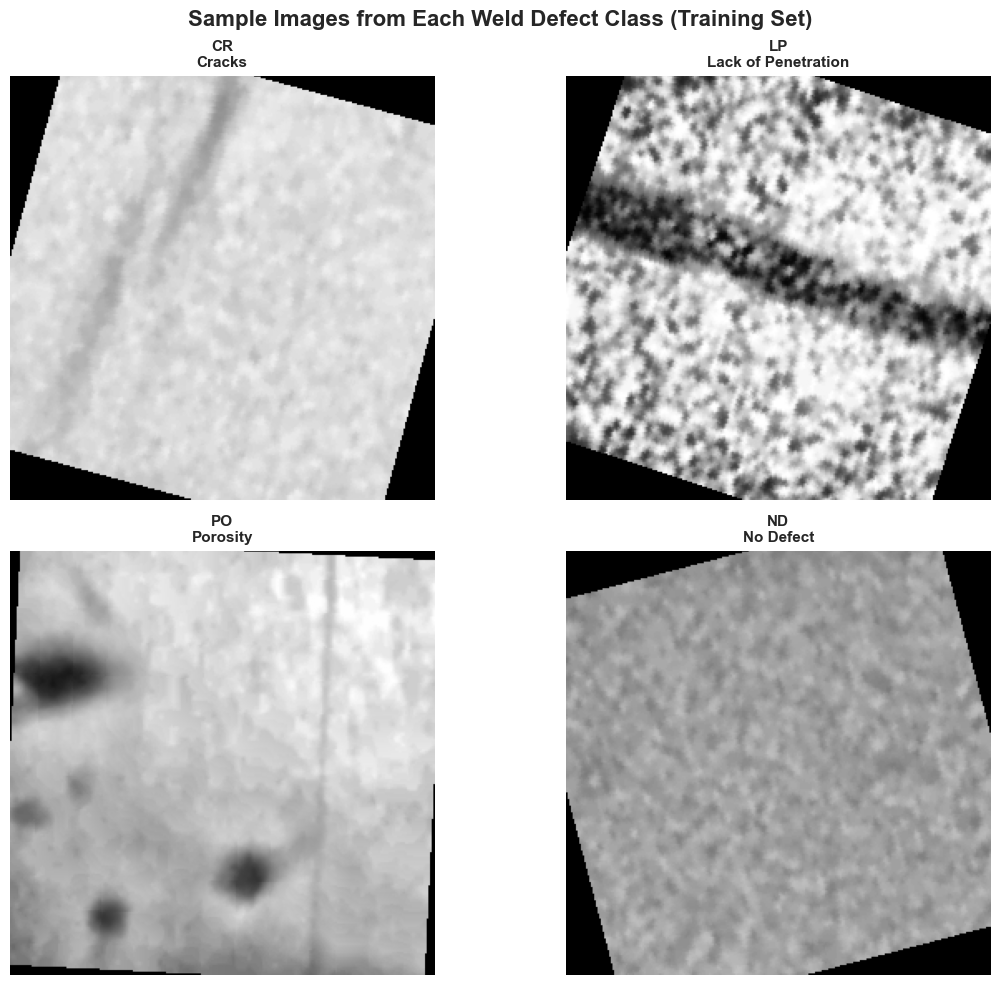

Sample images displayed!


In [364]:
# Display sample images from training set
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Sample Images from Each Weld Defect Class (Training Set)', 
             fontsize=16, fontweight='bold')

# Get one image per class
random_indices = np.random.choice(len(train_dataset), size=len(train_dataset), replace=False)
print(f"Random indices selected: {random_indices}")
class_samples = {}
for idx in random_indices:
    img, label = train_dataset[idx]
    #print image shape
    #print(f"Image shape: {img.shape}, Label: {label}")
    if label not in class_samples:
        class_samples[label] = img
    if len(class_samples) == CONFIG['num_classes']:
        break

# Display
for class_idx, ax in enumerate(axes.flat):
    if class_idx in class_samples:
        img = class_samples[class_idx]
        # Denormalize for display
        img_display = (img * 0.5 + 0.5).numpy()
        img_display = np.transpose(img_display, (1, 2, 0))
        # img_display = np.mean(img_display, axis=2)  # Convert to grayscale for display
        
        class_name = CLASS_NAMES[class_idx]
        ax.imshow(img_display, cmap='gray')
        ax.set_title(f"{class_name}\n{CLASS_LABELS[class_name]}", fontweight='bold', fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.show()
print("Sample images displayed!")


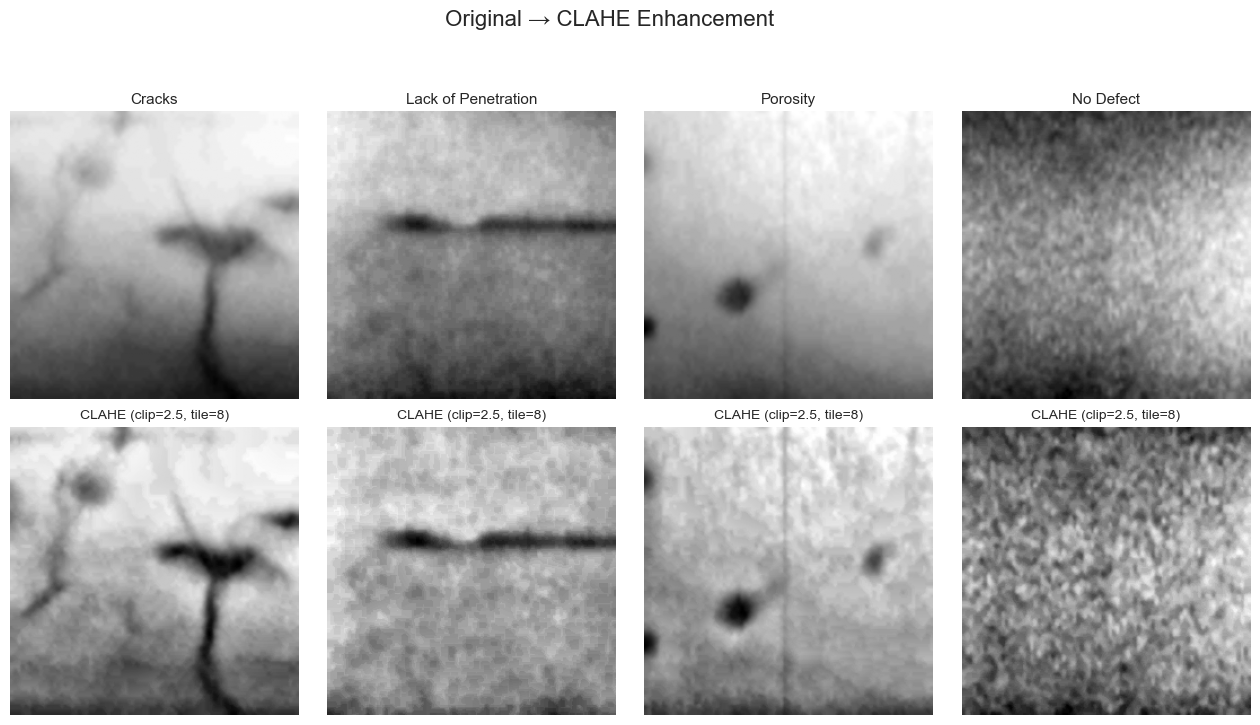

In [456]:
# Visualize Original (Row 1) vs CLAHE (Row 2)
import math

n_classes = len(CLASS_NAMES)
fig, axes = plt.subplots(2, n_classes, figsize=(4 * n_classes, 8))

fig.suptitle('Original → CLAHE Enhancement', fontsize=16, y=1)

# Define preprocessing parameters
clip = float(CONFIG.get('clahe_clip', 2.0))
tile = int(CONFIG.get('clahe_tile', 8))
kernel = int(CONFIG.get('gaussian_blur_kernel', 3))
radius = 2
eps = float(CONFIG.get('guided_filter_eps', 0.01))

clahe_op = cv2.createCLAHE(clipLimit=clip, tileGridSize=(tile, tile))

for idx, class_name in enumerate(CLASS_NAMES):

    # Fetch a sample image
    class_dir = os.path.join(TRAINING_PATH, class_name)
    files = [f for f in os.listdir(class_dir) if f.lower().endswith('.png')] if os.path.exists(class_dir) else []

    if not files:
        axes[0, idx].text(0.5, 0.5, 'No image', ha='center')
        axes[1, idx].text(0.5, 0.5, 'No image', ha='center')
        axes[0, idx].axis('off')
        axes[1, idx].axis('off')
        continue

    img_path = os.path.join(class_dir, files[0])
    img_gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if img_gray is None:
        axes[0, idx].text(0.5, 0.5, 'Load failed', ha='center')
        axes[1, idx].text(0.5, 0.5, 'Load failed', ha='center')
        axes[0, idx].axis('off')
        axes[1, idx].axis('off')
        continue

    # Resize
    img_resized = cv2.resize(img_gray, (CONFIG['image_size'], CONFIG['image_size']))

    # Guided filter or Gaussian blur
    if CONFIG.get('use_guided_filter', True):
        img_blurred = guided_filter(I=img_resized, p=img_resized, r=radius, eps=eps)
        img_blurred = np.uint8(np.clip(img_blurred, 0, 255))
    else:
        img_blurred = cv2.GaussianBlur(img_resized, (kernel, kernel), 0)

    # CLAHE
    img_clahe = clahe_op.apply(img_blurred)

    # Row 1 → Original image
    axes[0, idx].imshow(img_resized, cmap='gray')
    axes[0, idx].set_title(f"{CLASS_LABELS[class_name]}", fontsize=11)
    axes[0, idx].axis('off')

    # Row 2 → CLAHE
    axes[1, idx].imshow(img_clahe, cmap='gray')
    axes[1, idx].set_title(f"CLAHE (clip={clip}, tile={tile})", fontsize=10)
    axes[1, idx].axis('off')

# Minimal gap between rows & columns
plt.subplots_adjust(wspace=0.1, hspace=0.05)

plt.show()


## Part 9: Visualize Class Distribution

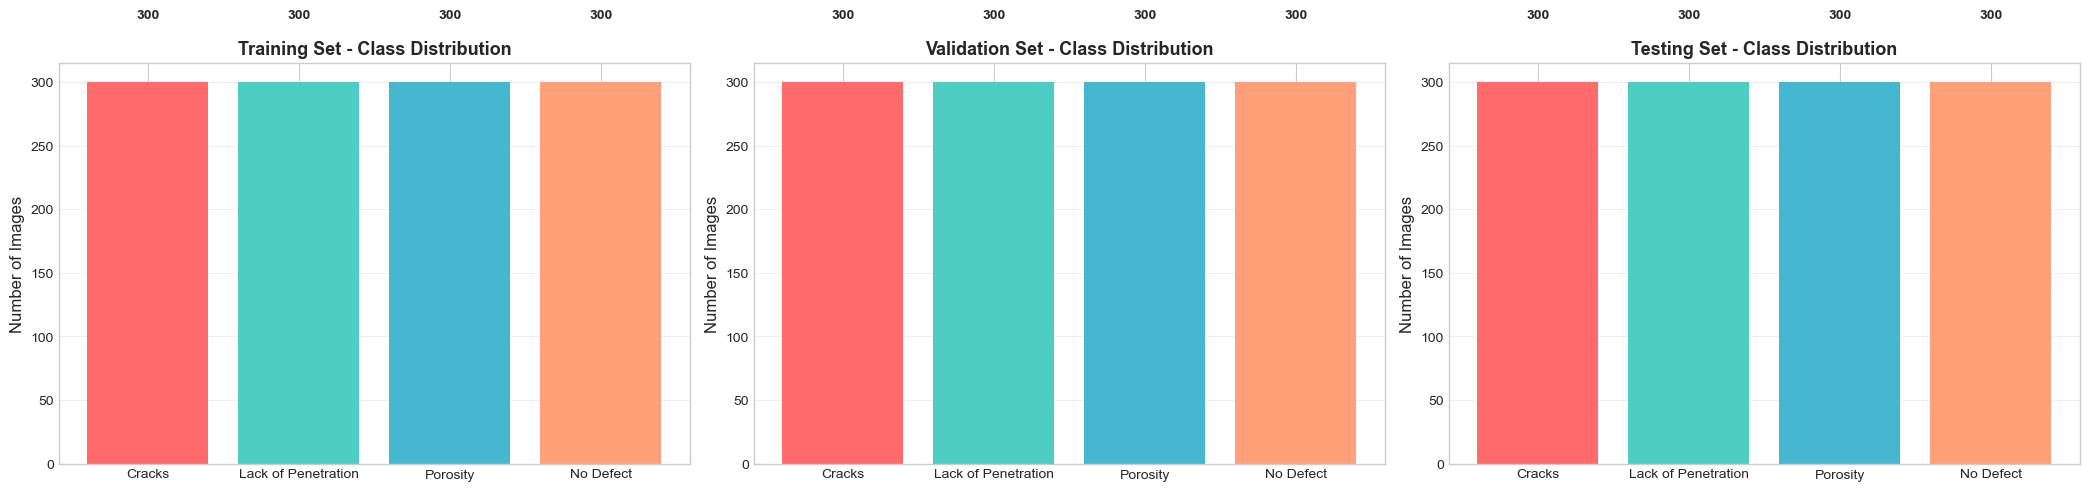


Class Distribution Summary:
Training: {'Cracks': 300, 'Lack of Penetration': 300, 'Porosity': 300, 'No Defect': 300}
Validation: {'Cracks': 300, 'Lack of Penetration': 300, 'Porosity': 300, 'No Defect': 300}
Testing:  {'Cracks': 300, 'Lack of Penetration': 300, 'Porosity': 300, 'No Defect': 300}


In [323]:
# Calculate class distribution
train_class_counts = [0] * CONFIG['num_classes']
val_class_counts = [0] * CONFIG['num_classes']
test_class_counts = [0] * CONFIG['num_classes']

for _, label in train_dataset:
    train_class_counts[label] += 1

for _, label in val_dataset:
    val_class_counts[label] += 1

for _, label in test_dataset:
    test_class_counts[label] += 1

# Plot class distribution
fig, axes = plt.subplots(1, 3, figsize=(21, 5))

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
class_labels_display = [CLASS_LABELS[name] for name in CLASS_NAMES]

# Training distribution
axes[0].bar(class_labels_display, train_class_counts, color=colors)
axes[0].set_ylabel('Number of Images', fontsize=12)
axes[0].set_title('Training Set - Class Distribution', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for i, count in enumerate(train_class_counts):
    axes[0].text(i, count + 50, str(count), ha='center', fontweight='bold')

# Validation distribution
axes[1].bar(class_labels_display, val_class_counts, color=colors)
axes[1].set_ylabel('Number of Images', fontsize=12)
axes[1].set_title('Validation Set - Class Distribution', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for i, count in enumerate(val_class_counts):
    axes[1].text(i, count + 50, str(count), ha='center', fontweight='bold')

# Testing distribution
axes[2].bar(class_labels_display, test_class_counts, color=colors)
axes[2].set_ylabel('Number of Images', fontsize=12)
axes[2].set_title('Testing Set - Class Distribution', fontsize=13, fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)
for i, count in enumerate(test_class_counts):
    axes[2].text(i, count + 50, str(count), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nClass Distribution Summary:")
print(f"Training: {dict(zip(class_labels_display, train_class_counts))}")
print(f"Validation: {dict(zip(class_labels_display, val_class_counts))}")
print(f"Testing:  {dict(zip(class_labels_display, test_class_counts))}")


## Part 10: Define CNN Model

In [338]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

# ---------------------------
# Multi-Head Self Attention
# ---------------------------
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, dim, num_heads=8, qkv_bias=True, attn_drop=0.1, proj_drop=0.1):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5

        assert dim % num_heads == 0, "dim must be divisible by num_heads"

        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, x):
        B, N, C = x.shape

        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        out = (attn @ v).transpose(1, 2).reshape(B, N, C)
        out = self.proj(out)
        out = self.proj_drop(out)

        return out
  
# ---------------------------
# Feed-Forward Network
# ---------------------------
class FeedForward(nn.Module):
    def __init__(self, dim, hidden_dim, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)


# ---------------------------
# Transformer Encoder Block
# ---------------------------
class TransformerBlock(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        
        self.attn = MultiHeadSelfAttention(
                dim, num_heads=num_heads, attn_drop=dropout, proj_drop=dropout
        )
        
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = FeedForward(dim, int(dim * mlp_ratio), dropout=dropout)

    def forward(self, x, H, W):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

# ---------------------------
# Attention Pooling
# ---------------------------
class AttentionPooling(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(dim, dim // 2),
            nn.Tanh(),
            nn.Linear(dim // 2, 1)
        )
    
    def forward(self, x):
        attn_weights = self.attention(x)
        attn_weights = F.softmax(attn_weights, dim=1)
        out = (x * attn_weights).sum(dim=1)
        return out

In [424]:
import torchvision.models as models
import torch.nn as nn
import torch.nn.functional as F

class ResNet50WithTransformer(nn.Module):
    def __init__(self, num_classes, num_heads=8, trans_dim=512):
        super().__init__()

        backbone = models.resnet50(pretrained=True)

        # Remove avgpool + fc, keep CNN only
        self.cnn = nn.Sequential(
            backbone.conv1, backbone.bn1, backbone.relu,
            backbone.maxpool,
            backbone.layer1,
            backbone.layer2,
            backbone.layer3,
            backbone.layer4
        )

        # output of layer4 is: (B, 2048, 8, 8) for 256×256 input
        self.proj = nn.Linear(2048, trans_dim)

        # 1 Transformer block (you can use more)
        self.transformer = TransformerBlock(
            dim=trans_dim,
            num_heads=num_heads,
        )

        # Attention pooling OR CLS token
        self.pool = AttentionPooling(trans_dim)

        self.fc = nn.Linear(trans_dim, num_classes)
        self.H = 8
        self.W = 8

    def forward(self, x):

        # 1) CNN features
        x = self.cnn(x)               # (B, 2048, 8, 8)

        # 2) Flatten spatial → sequence
        B, C, H, W = x.shape
        x = x.view(B, C, H*W).permute(0, 2, 1)  # (B, 64, 2048)

        # 3) Reduce embedding dimension
        x = self.proj(x)              # (B, 64, trans_dim)

        # 4) Transformer layer
        x = self.transformer(x, self.H, self.W)       # (B, 64, trans_dim)

        # 5) Attention pooling
        x = self.pool(x)              # (B, trans_dim)

        # 6) Classifier
        x = self.fc(x)                # (B, num_classes)
        return x


In [425]:
class ResNet50WithMultiScaleFusion(nn.Module):
    def __init__(self, num_classes, num_heads=8, trans_dim=512):
        super().__init__()

        backbone = models.resnet50(pretrained=True)

        # Split ResNet into stages
        self.stage1 = nn.Sequential(
            backbone.conv1, backbone.bn1, backbone.relu,
            backbone.maxpool,
            backbone.layer1,
            backbone.layer2
        )
        self.layer3 = backbone.layer3  # Output: (B, 1024, 16, 16)
        self.layer4 = backbone.layer4  # Output: (B, 2048, 8, 8)

        # === Transformer for Layer 3 features ===
        self.proj_layer3 = nn.Linear(1024, trans_dim)
        self.transformer_layer3 = nn.ModuleList([
            TransformerBlock(dim=trans_dim, num_heads=num_heads)
            for _ in range(2)  # 2 transformer blocks
        ])
        self.pool_layer3 = AttentionPooling(trans_dim)

        # === Transformer for Layer 4 features ===
        self.proj_layer4 = nn.Linear(2048, trans_dim)
        self.transformer_layer4 = nn.ModuleList([
            TransformerBlock(dim=trans_dim, num_heads=num_heads)
            for _ in range(4)  # 2 transformer blocks
        ])
        self.pool_layer4 = AttentionPooling(trans_dim)

        # === Multi-scale Fusion ===
        self.fusion = nn.Sequential(
            nn.Linear(trans_dim * 2, trans_dim),  # Concatenate layer3 + layer4
            nn.ReLU(),
            nn.Dropout(0.1)
        )

        # === Classifier ===
        self.fc = nn.Linear(trans_dim, num_classes)

    def forward(self, x):
        # Stage 1 & 2
        x = self.stage1(x)  # (B, 512, 32, 32)

        # === Process Layer 3 ===
        x3 = self.layer3(x)  # (B, 1024, 16, 16)
        B, C3, H3, W3 = x3.shape
        
        # Flatten and project
        x3_flat = x3.view(B, C3, H3*W3).permute(0, 2, 1)  # (B, 256, 1024)
        x3_trans = self.proj_layer3(x3_flat)  # (B, 256, trans_dim)
        
        # Apply transformers
        for transformer in self.transformer_layer3:
            x3_trans = transformer(x3_trans, H3, W3)
        
        # Pool to get global representation
        x3_pooled = self.pool_layer3(x3_trans)  # (B, trans_dim)

        # === Process Layer 4 ===
        x4 = self.layer4(x3)  # (B, 2048, 8, 8)
        B, C4, H4, W4 = x4.shape
        
        # Flatten and project
        x4_flat = x4.view(B, C4, H4*W4).permute(0, 2, 1)  # (B, 64, 2048)
        x4_trans = self.proj_layer4(x4_flat)  # (B, 64, trans_dim)
        
        # Apply transformers
        for transformer in self.transformer_layer4:
            x4_trans = transformer(x4_trans, H4, W4)
        
        # Pool to get global representation
        x4_pooled = self.pool_layer4(x4_trans)  # (B, trans_dim)

        # === Fuse Multi-Scale Features ===
        x_fused = torch.cat([x3_pooled, x4_pooled], dim=1)  # (B, trans_dim*2)
        x_fused = self.fusion(x_fused)  # (B, trans_dim)

        # === Final Classification ===
        x = self.fc(x_fused)  # (B, num_classes)
        return x

In [426]:
class ResNet50WithTransformerSkip(nn.Module):
    def __init__(self, num_classes, num_heads=8, trans_dim=512):
        super().__init__()

        backbone = models.resnet50(pretrained=True)

        self.stage1 = nn.Sequential(
            backbone.conv1, backbone.bn1, backbone.relu,
            backbone.maxpool,
            backbone.layer1,
            backbone.layer2
        )
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4

        # Transformers
        self.proj_layer3 = nn.Linear(1024, trans_dim)
        self.trans3 = TransformerBlock(dim=trans_dim, num_heads=num_heads)
        
        self.proj_layer4 = nn.Linear(2048, trans_dim)
        self.trans4 = TransformerBlock(dim=trans_dim, num_heads=num_heads)

        # Pooling
        self.pool3 = AttentionPooling(trans_dim)
        self.pool4 = AttentionPooling(trans_dim)

        # Fusion with learnable weights
        self.alpha = nn.Parameter(torch.tensor(0.5))  # Weight for layer3 vs layer4

        self.fc = nn.Linear(trans_dim, num_classes)

    def forward(self, x):
        x = self.stage1(x)

        # Layer 3 path
        x3 = self.layer3(x)
        B, C3, H3, W3 = x3.shape
        x3_seq = x3.view(B, C3, -1).permute(0, 2, 1)
        x3_trans = self.trans3(self.proj_layer3(x3_seq), H3, W3)
        x3_pool = self.pool3(x3_trans)

        # Layer 4 path
        x4 = self.layer4(x3)  # Continue from layer3
        B, C4, H4, W4 = x4.shape
        x4_seq = x4.view(B, C4, -1).permute(0, 2, 1)
        x4_trans = self.trans4(self.proj_layer4(x4_seq), H4, W4)
        x4_pool = self.pool4(x4_trans)

        # Weighted fusion
        alpha = torch.sigmoid(self.alpha)
        x_fused = alpha * x3_pool + (1 - alpha) * x4_pool

        return self.fc(x_fused)

In [427]:
from torchvision import models

# Choose backbone: 'custom', 'resnet50', 'efficientnet_b0'
BACKBONE = 'resnet50_transformer'  # change as needed
USE_PRETRAINED = True
FREEZE_BACKBONE = False  # set False to fine-tune entire model

if BACKBONE == 'resnet50':
    # Load ResNet50 and replace final fc
    backbone = models.resnet50(pretrained=USE_PRETRAINED)
    in_features = backbone.fc.in_features
    backbone.fc = nn.Linear(in_features, CONFIG['num_classes'])
    model = backbone.to(device)
    if FREEZE_BACKBONE:
        for name, param in model.named_parameters():
            if 'fc' not in name:
                param.requires_grad = False

elif BACKBONE == 'resnet50_transformer':
    model = ResNet50WithTransformerSkip(
        num_classes=CONFIG['num_classes'],
        num_heads=8,
        trans_dim=512
    ).to(device)
    
    if FREEZE_BACKBONE:
        # Freeze CNN backbone layers (ResNet parts)
        for name, param in model.named_parameters():
            if name.startswith(("stage1", "layer3", "layer4")):
                param.requires_grad = False
                print(f"Frozen: {name}")
else:
    raise ValueError(f'Unsupported BACKBONE: {BACKBONE}')

def count_trainable_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print('Model created!')
print(f'Backbone: {BACKBONE}, pretrained={USE_PRETRAINED}, freeze_backbone={FREEZE_BACKBONE}')
print(f'Trainable parameters: {count_trainable_params(model):,}')
print('\nModel Summary:')
print(model)


Model created!
Backbone: resnet50_transformer, pretrained=True, freeze_backbone=False
Trainable parameters: 31,651,911

Model Summary:
ResNet50WithTransformerSkip(
  (stage1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1

## Part 11: Define Loss Function and Optimizer

In [428]:
# Loss function and optimizer
criterion = nn.CrossEntropyLoss()

# Only include parameters that require gradients (useful if backbone frozen)
trainable_params = filter(lambda p: p.requires_grad, model.parameters())
optimizer = optim.Adam(trainable_params, lr=CONFIG['learning_rate'])

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=10)

print('Loss function: CrossEntropyLoss')
print(f'Optimizer: Adam (lr={CONFIG['learning_rate']})')
print('Scheduler: ReduceLROnPlateau')


Loss function: CrossEntropyLoss
Optimizer: Adam (lr=0.001)
Scheduler: ReduceLROnPlateau


## Part 12: Define Training Functions

In [429]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """
    Train for one epoch
    """
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        if (batch_idx + 1) % 10 == 0:
            print(f'  Batch [{batch_idx + 1}/{len(train_loader)}], Loss: {loss.item():.4f}')
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc

def validate(model, val_loader, criterion, device):
    """
    Validate model
    """
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(val_loader)
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc

print("Training functions defined!")


Training functions defined!


## Part 13: Train the Model

In [442]:
import time
import os
import torch

# Ensure output folder exists
os.makedirs(FOLDER_PATH, exist_ok=True)

# Single checkpoint file
CHECKPOINT_PATH = os.path.join(FOLDER_PATH, 'training_checkpoint.pth')

# Initialize training state
def initialize_training():
    """Load checkpoint if exists, otherwise start fresh"""
    if os.path.exists(CHECKPOINT_PATH):
        print(f"Loading checkpoint from {CHECKPOINT_PATH}...")
        checkpoint = torch.load(CHECKPOINT_PATH, map_location=CONFIG['device'])
        
        # Restore everything
        model.load_state_dict(checkpoint['model_state'])
        optimizer.load_state_dict(checkpoint['optimizer_state'])
        scheduler.load_state_dict(checkpoint['scheduler_state'])
        
        return {
            'start_epoch': checkpoint['epoch'] + 1,
            'history': checkpoint['history'],
            'best_val_acc': checkpoint['best_val_acc'],
            'patience_counter': checkpoint['patience_counter'],
            'run_id': checkpoint['run_id']
        }
    else:
        print("Starting fresh training...")
        return {
            'start_epoch': 0,
            'history': {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []},
            'best_val_acc': 0,
            'patience_counter': 0,
            'run_id': time.strftime("%Y%m%d_%H%M%S")
        }

# Load or initialize
state = initialize_training()
start_epoch = state['start_epoch']
history = state['history']
best_val_acc = state['best_val_acc']
patience_counter = state['patience_counter']
run_id = state['run_id']

print(f"Run ID: {run_id}")
print(f"Starting from epoch {start_epoch + 1}/{CONFIG['epochs']}\n")

# Best model path
best_model_path = os.path.join(FOLDER_PATH, f"best_model_{run_id}.pth")

# Training loop
patience = 10

for epoch in range(start_epoch, CONFIG['epochs']):
    print(f"Epoch [{epoch+1}/{CONFIG['epochs']}]")
    
    # Train and validate
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, CONFIG['device'])
    val_loss, val_acc = validate(model, val_loader, criterion, CONFIG['device'])
    
    # Update history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f'  Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f}%')
    print(f'  Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%')
    
    # Scheduler step
    scheduler.step(val_acc)
    
    # Check for improvement
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
        print(f"  ✓ New best model saved (val_acc={best_val_acc:.2f}%)")
    else:
        patience_counter += 1
        print(f"  No improvement ({patience_counter}/{patience})")
    
    # Save checkpoint
    torch.save({
        'epoch': epoch,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'scheduler_state': scheduler.state_dict(),
        'history': history,
        'best_val_acc': best_val_acc,
        'patience_counter': patience_counter,
        'run_id': run_id
    }, CHECKPOINT_PATH)
    
    # Early stopping
    if patience_counter >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        break
    
    print()

print("\n✓ Training completed!")
print(f"Best model: {best_model_path}")
print(f"Best validation accuracy: {best_val_acc:.2f}%")

# Optional: Remove checkpoint after successful completion
# os.remove(CHECKPOINT_PATH)

Loading checkpoint from C:\\Users\\mp29984\\Desktop\\RIAWELC\\training_checkpoint.pth...
Run ID: 20251124_135602
Starting from epoch 43/100

Epoch [43/100]
  Batch [10/248], Loss: 0.0102
  Batch [20/248], Loss: 0.0357
  Batch [30/248], Loss: 0.1021
  Batch [40/248], Loss: 0.0023
  Batch [50/248], Loss: 0.0029
  Batch [60/248], Loss: 0.0234
  Batch [70/248], Loss: 0.0049
  Batch [80/248], Loss: 0.0020
  Batch [90/248], Loss: 0.0025
  Batch [100/248], Loss: 0.0078
  Batch [110/248], Loss: 0.0122
  Batch [120/248], Loss: 0.0203
  Batch [130/248], Loss: 0.0506
  Batch [140/248], Loss: 0.0294
  Batch [150/248], Loss: 0.0091
  Batch [160/248], Loss: 0.0035
  Batch [170/248], Loss: 0.1785
  Batch [180/248], Loss: 0.0107
  Batch [190/248], Loss: 0.0018
  Batch [200/248], Loss: 0.0033
  Batch [210/248], Loss: 0.0585
  Batch [220/248], Loss: 0.0254
  Batch [230/248], Loss: 0.0025
  Batch [240/248], Loss: 0.0329
  Train Loss: 0.0237, Acc: 99.22%
  Val Loss: 0.0159, Acc: 99.49%
  No improvement (1

## Part 14: Plot Training History

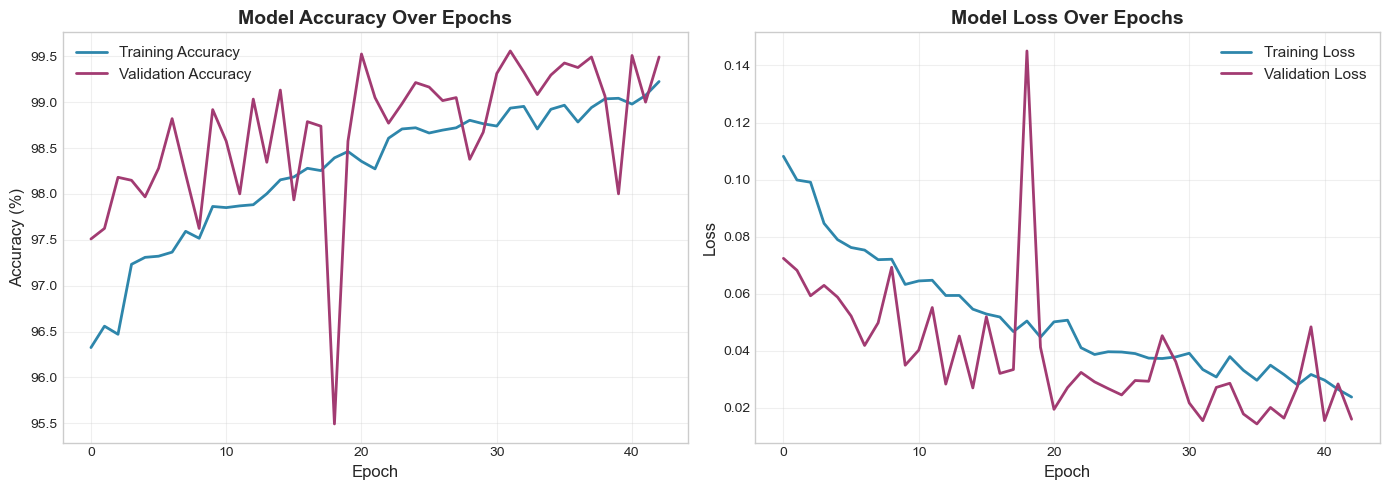

Best epoch: 32
Best validation accuracy: 99.56%


In [443]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(history['train_acc'], label='Training Accuracy', linewidth=2, color='#2E86AB')
ax1.plot(history['val_acc'], label='Validation Accuracy', linewidth=2, color='#A23B72')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Accuracy (%)', fontsize=12)
ax1.set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)

# Loss
ax2.plot(history['train_loss'], label='Training Loss', linewidth=2, color='#2E86AB')
ax2.plot(history['val_loss'], label='Validation Loss', linewidth=2, color='#A23B72')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print best metrics
best_epoch = np.argmax(history['val_acc'])
print(f"Best epoch: {best_epoch + 1}")
print(f"Best validation accuracy: {history['val_acc'][best_epoch]:.2f}%")


In [444]:
print("="*60)
print("Training results")
print("="*60)

model.eval()
train_correct_count = 0
train_total = 0
y_true_train = []
y_pred_train = []

with torch.no_grad():
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        train_total += labels.size(0)
        train_correct_count += (predicted == labels).sum().item()

        y_true_train.extend(labels.cpu().numpy())
        y_pred_train.extend(predicted.cpu().numpy())

train_accuracy = 100 * train_correct_count / train_total if train_total > 0 else 0

print("\n" + "="*60)
print("TRAIN SET PERFORMANCE")
print("="*60)
print(f"Train Accuracy: {train_accuracy:.2f}%")
print(f"Correct: {train_correct_count}/{train_total}")


# Classification report
print("\n" + "="*60)
print("CLASSIFICATION REPORT ON TRAIN SET")
print("="*60)
target_names = [CLASS_LABELS[name] for name in CLASS_NAMES]
if len(y_true_train) == 0:
    print("No training predictions collected.")
else:
    print(classification_report(y_true_train, y_pred_train, target_names=target_names))


Training results



TRAIN SET PERFORMANCE
Train Accuracy: 99.41%
Correct: 15770/15863

CLASSIFICATION REPORT ON TRAIN SET
                     precision    recall  f1-score   support

             Cracks       0.99      0.99      0.99      4962
Lack of Penetration       0.99      0.99      0.99      2893
           Porosity       1.00      1.00      1.00      4108
          No Defect       1.00      1.00      1.00      3900

           accuracy                           0.99     15863
          macro avg       0.99      0.99      0.99     15863
       weighted avg       0.99      0.99      0.99     15863



In [445]:
print("="*60)
print("Validation results")
print("="*60)

model.eval()
validation_correct_count = 0
validation_total = 0
y_true_validation = []
y_pred_validation = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        validation_total += labels.size(0)
        validation_correct_count += (predicted == labels).sum().item()

        y_true_validation.extend(labels.cpu().numpy())
        y_pred_validation.extend(predicted.cpu().numpy())

validation_accuracy = 100 * validation_correct_count / validation_total if validation_total > 0 else 0

print("\n" + "="*60)
print("VALIDATION SET PERFORMANCE")
print("="*60)
print(f"Validation Accuracy: {validation_accuracy:.2f}%")
print(f"Correct: {validation_correct_count}/{validation_total}")


# Classification report
print("\n" + "="*60)
print("CLASSIFICATION REPORT ON VALIDATION SET")
print("="*60)
target_names = [CLASS_LABELS[name] for name in CLASS_NAMES]
if len(y_true_validation) == 0:
    print("No validation predictions collected.")
else:
    print(classification_report(y_true_validation, y_pred_validation, target_names=target_names))


Validation results



VALIDATION SET PERFORMANCE
Validation Accuracy: 99.49%
Correct: 6070/6101

CLASSIFICATION REPORT ON VALIDATION SET
                     precision    recall  f1-score   support

             Cracks       1.00      1.00      1.00      1908
Lack of Penetration       0.99      0.99      0.99      1113
           Porosity       1.00      0.99      0.99      1580
          No Defect       1.00      1.00      1.00      1500

           accuracy                           0.99      6101
          macro avg       0.99      0.99      0.99      6101
       weighted avg       0.99      0.99      0.99      6101



## Part 15: Load Best Model and Evaluate on Test Set

In [446]:
# Load best model
model.load_state_dict(torch.load(best_model_path))
print("Best model loaded!")

# Evaluate on test set
model.eval()
test_correct = 0
test_total = 0
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

test_accuracy = 100 * test_correct / test_total

print("\n" + "="*60)
print("TEST SET PERFORMANCE")
print("="*60)
print(f"Test Accuracy: {test_accuracy:.2f}%")
print(f"Correct: {test_correct}/{test_total}")

# Classification report
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
target_names = [CLASS_LABELS[name] for name in CLASS_NAMES]
print(classification_report(y_true, y_pred, target_names=target_names))


Best model loaded!

TEST SET PERFORMANCE
Test Accuracy: 99.67%
Correct: 2435/2443

CLASSIFICATION REPORT
                     precision    recall  f1-score   support

             Cracks       0.99      1.00      1.00       765
Lack of Penetration       1.00      0.99      0.99       446
           Porosity       1.00      1.00      1.00       632
          No Defect       1.00      1.00      1.00       600

           accuracy                           1.00      2443
          macro avg       1.00      1.00      1.00      2443
       weighted avg       1.00      1.00      1.00      2443



## Part 17: Confusion Matrix

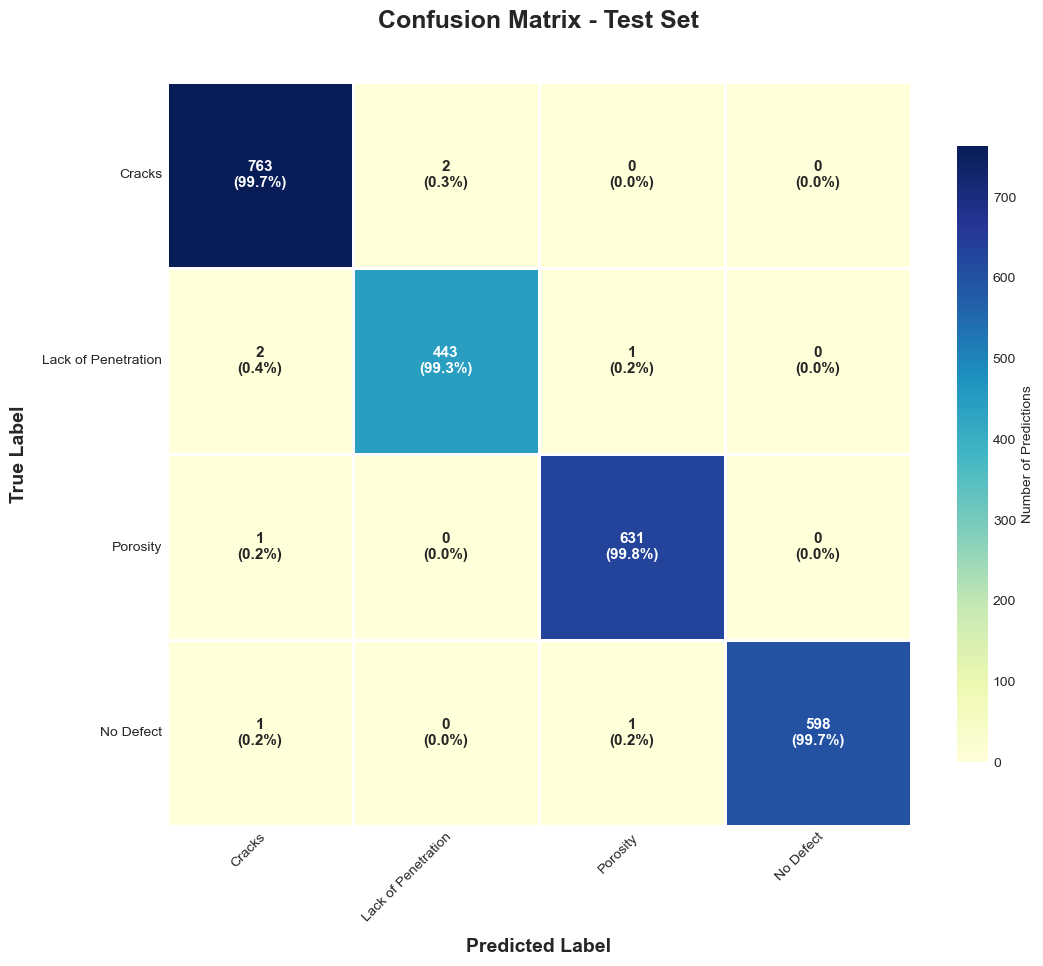

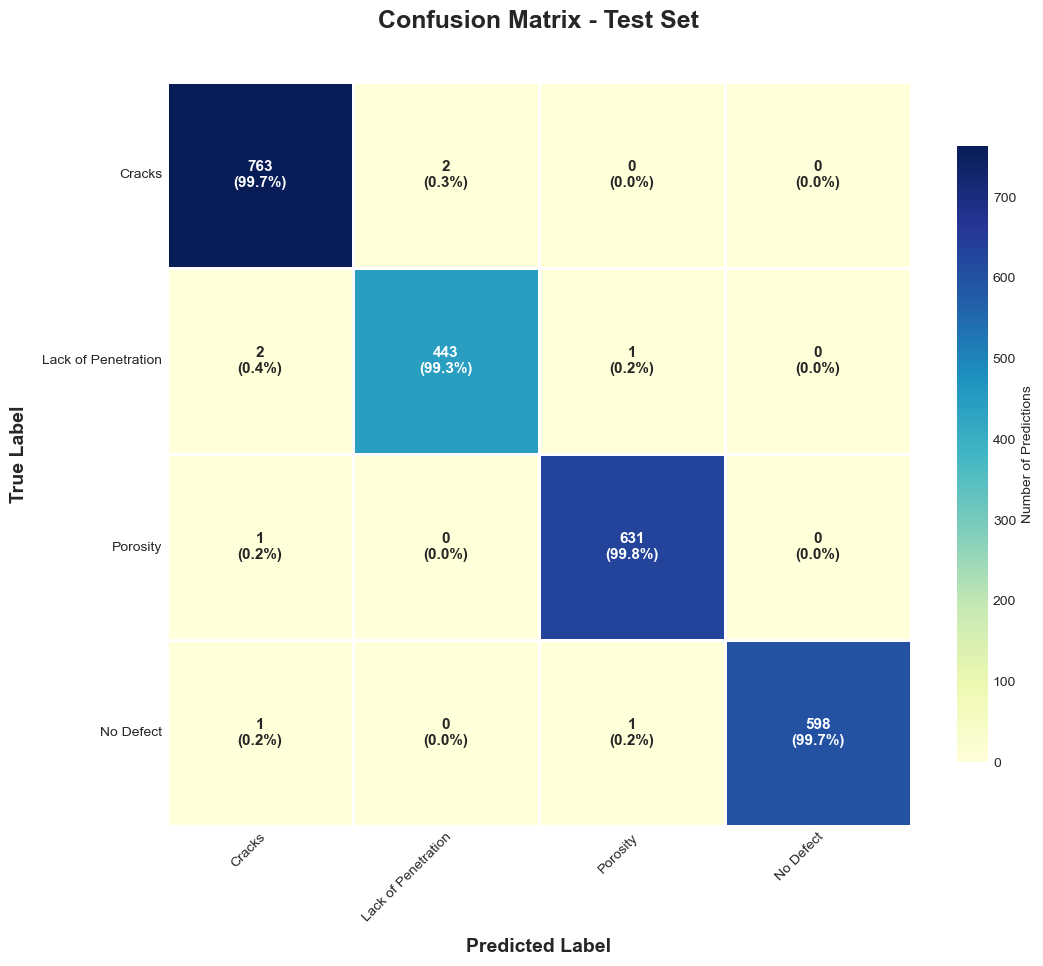

In [447]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

def plot_beautiful_confusion_matrix(y_true, y_pred, target_names):
    """Beautiful confusion matrix with counts and percentages"""
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Create annotations with counts and percentages
    annotations = np.empty_like(cm, dtype=object)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            count = cm[i, j]
            percentage = cm_normalized[i, j]
            annotations[i, j] = f'{count}\n({percentage:.1f}%)'
    
    # Plot heatmap
    sns.heatmap(cm, annot=annotations, fmt='', cmap='YlGnBu',
                xticklabels=target_names,
                yticklabels=target_names,
                cbar_kws={'label': 'Number of Predictions', 'shrink': 0.8},
                linewidths=2, linecolor='white',
                square=True, ax=ax,
                vmin=0, vmax=cm.max(),
                annot_kws={'size': 11, 'weight': 'bold'})
    
    # Styling
    ax.set_title('Confusion Matrix - Test Set\n', 
                 fontsize=18, fontweight='bold', pad=20)
    ax.set_ylabel('True Label', fontsize=14, fontweight='bold', labelpad=10)
    ax.set_xlabel('Predicted Label', fontsize=14, fontweight='bold', labelpad=10)
    
    # Rotate labels for better readability
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
    plt.setp(ax.get_yticklabels(), rotation=0)
    
    # Add metrics text box
    # metrics_text = f'Accuracy: {accuracy:.3f}\nPrecision: {precision:.3f}\nRecall: {recall:.3f}\nF1-Score: {f1:.3f}'
    # props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    # ax.text(1.15, 0.5, metrics_text, transform=ax.transAxes, fontsize=12,
    #         verticalalignment='center', bbox=props, fontweight='bold')
    
    # plt.tight_layout()
    # plt.show()
    
    return fig

# Usage
plot_beautiful_confusion_matrix(y_true, y_pred, target_names)

## Part 18: Visualize Predictions

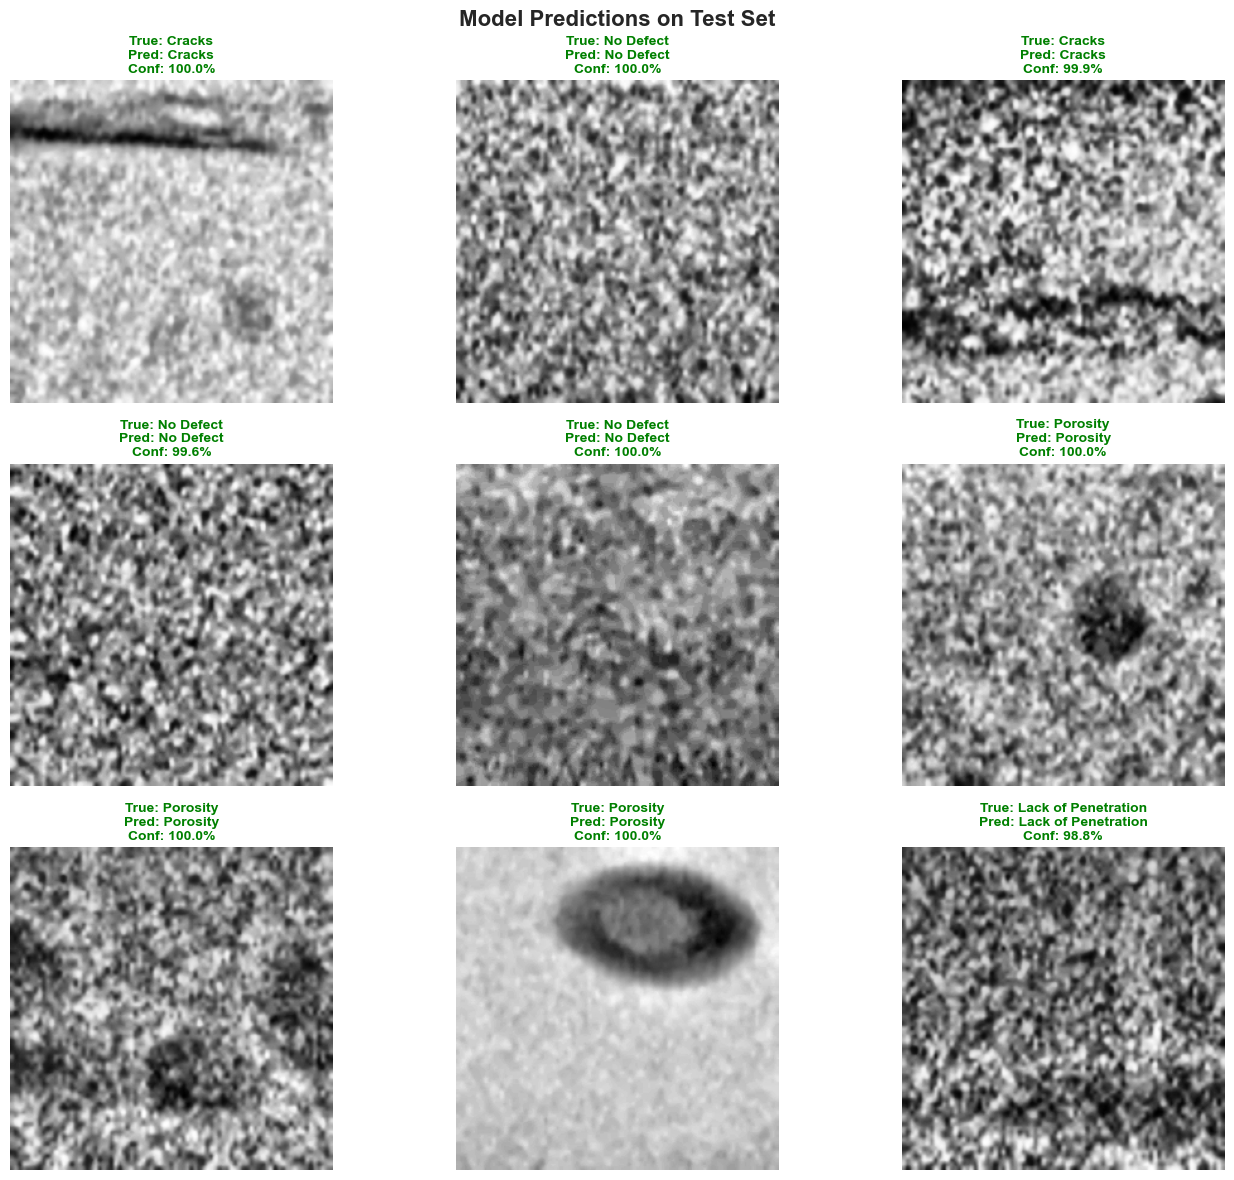

In [451]:
# Get predictions with probabilities
model.eval()
y_pred_probs_all = []
test_images = []
test_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        
        y_pred_probs_all.extend(probs.cpu().numpy())
        test_images.extend(images.cpu().numpy())
        test_labels.extend(labels.numpy())

# Visualize some predictions
fig, axes = plt.subplots(3, 3, figsize=(14, 12))
fig.suptitle('Model Predictions on Test Set', fontsize=16, fontweight='bold')

random_indices = np.random.choice(len(test_images), size=min(9, len(test_images)), replace=False)

for idx, ax in enumerate(axes.flat):
    if idx < min(9, len(test_images)):
        img = test_images[random_indices[idx]]
        true_label_idx = test_labels[random_indices[idx]]
        pred_probs = y_pred_probs_all[random_indices[idx]]
        pred_label_idx = np.argmax(pred_probs)
        confidence = np.max(pred_probs) * 100
        
        true_label = CLASS_LABELS[CLASS_NAMES[true_label_idx]]
        pred_label = CLASS_LABELS[CLASS_NAMES[pred_label_idx]]
        
        # Color green if correct, red if incorrect
        color = 'green' if true_label_idx == pred_label_idx else 'red'
        
        # Denormalize and convert to display format
        img_display = (img * 0.5 + 0.5)
        img_display = np.transpose(img_display, (1, 2, 0))
        img_display = np.mean(img_display, axis=2)  # Grayscale
        
        ax.imshow(img_display, cmap='gray')
        title_text = f'True: {true_label}\nPred: {pred_label}\nConf: {confidence:.1f}%'
        ax.set_title(title_text, color=color, fontweight='bold', fontsize=10)
        ax.axis('off')

plt.tight_layout()
plt.show()


## Part 19: Save the Model

In [449]:
# Save model
saved_model_path = f"{FOLDER_PATH}riawelc_pytorch_model_{id}.pth"
saved_model_path_full = f"{FOLDER_PATH}riawelc_pytorch_model_full_{id}.pth"
torch.save(model.state_dict(), saved_model_path)
print(f"Model weights saved as '{saved_model_path}'")

# Save entire model
torch.save(model, saved_model_path_full)
print(f"Full model saved as '{saved_model_path_full}'")

# Save class mapping
import json
class_mapping = {
    'class_names': CLASS_NAMES,
    'class_labels': CLASS_LABELS
}
with open('class_mapping.json', 'w') as f:
    json.dump(class_mapping, f, indent=2)
print("Class mapping saved as 'class_mapping.json'")


Model weights saved as 'C:\\Users\\mp29984\\Desktop\\RIAWELC\\riawelc_pytorch_model_2025-11-23---17-25-07.pth'
Full model saved as 'C:\\Users\\mp29984\\Desktop\\RIAWELC\\riawelc_pytorch_model_full_2025-11-23---17-25-07.pth'
Class mapping saved as 'class_mapping.json'


## Part 20: Predict on New Images

In [450]:
def predict_single_image(image_path, model, device, classes, labels):
    """
    Predict the class of a single radiographic weld image
    
    Args:
        image_path: Path to the PNG image
        model: Trained PyTorch model
        device: Device (cpu or cuda)
        classes: List of class names
        labels: Dictionary mapping class names to full labels
    
    Returns:
        Dictionary with prediction results
    """
    # Load and preprocess image (grayscale)
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    if img is None:
        return {'error': f'Could not load image from {image_path}'}
    
    # Resize to CONFIG image_size
    img = cv2.resize(img, (CONFIG['image_size'], CONFIG['image_size']))
    
    # Apply CLAHE if enabled
    if CONFIG.get('use_clahe', False):
        clip = float(CONFIG.get('clahe_clip', 2.0))
        tile = int(CONFIG.get('clahe_tile', 8))
        clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=(tile, tile))
        img = clahe.apply(img)
    
    # Convert to RGB
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    
    # Continue with existing transforms and prediction
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])
    img_tensor = transform(Image.fromarray(img)).unsqueeze(0).to(device)
    
    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        probs = torch.softmax(output, dim=1)[0]
        predicted_idx = torch.argmax(probs).item()
        confidence = probs[predicted_idx].item() * 100
    
    all_probs = {labels[classes[i]]: probs[i].item()*100 for i in range(len(classes))}
    
    return {
        'predicted_class': classes[predicted_idx],
        'predicted_label': labels[classes[predicted_idx]],
        'confidence': confidence,
        'all_probabilities': all_probs
    }

# Example: Test on one image from the test set
print("Testing prediction function on a test image...\n")
test_image_path = os.path.join(TESTING_PATH, CLASS_NAMES[0], 
                               os.listdir(os.path.join(TESTING_PATH, CLASS_NAMES[0]))[0])

result = predict_single_image(test_image_path, model, device, CLASS_NAMES, CLASS_LABELS)

print(f"Predicted Class: {result['predicted_class']}")
print(f"Label: {result['predicted_label']}")
print(f"Confidence: {result['confidence']:.2f}%")
print(f"\nAll Probabilities:")
for label, prob in result['all_probabilities'].items():
    print(f"  {label:30}: {prob:.2f}%")

Testing prediction function on a test image...

Predicted Class: CR
Label: Cracks
Confidence: 100.00%

All Probabilities:
  Cracks                        : 100.00%
  Lack of Penetration           : 0.00%
  Porosity                      : 0.00%
  No Defect                     : 0.00%
